# Children's Speech ASR — Age-Specific Whisper-small + LoRA Models

This notebook trains **one dedicated LoRA adapter per age group**, rather than a single
general-purpose model.  The hypothesis is that each age group has distinct acoustic
characteristics (formant frequencies, speaking rate, pronunciation clarity) that a
specialised model can exploit.

| Age bucket | Acoustic profile | Expected challenge |
|---|---|---|
| **3–4** | High F0, heavy consonant deletion, short utterances | Least data; highest WER |
| **5–7** | Transitional; some adult-like features emerging | Medium difficulty |
| **8–11** | Near-adult phonology, most training data | Easiest; most data |

**Evaluation protocol** (identical across all notebooks):
- Each model is trained and evaluated only on its own age bucket's data
- WER is computed with the same jiwer pipeline (lower-case, no punctuation)
- Zero-shot Whisper-small is the common baseline for all buckets
- Results are compared against the **general LoRA** model from `notebook_whisper_lora.ipynb`

In [1]:
# Set cache directories (UCL lab machines)
import os
os.environ['HF_HOME']         = '/cs/student/project_msc/2025/dsml/nmxian/huggingface_cache'
os.environ['TORCH_HOME']      = '/cs/student/project_msc/2025/dsml/nmxian/torch_cache'
os.environ['KAGGLEHUB_CACHE'] = '/cs/student/project_msc/2025/dsml/nmxian/kaggle_cache'

In [2]:
# ── 0. Install required libraries ────────────────────────────────────────────
#!pip install -q transformers datasets soundfile librosa jiwer scikit-learn peft accelerate evaluate numpy pandas matplotlib

In [3]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import os, json, random
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import soundfile as sf
import librosa
import jiwer

from torch.utils.data import Dataset
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel

print(f"torch       : {torch.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")
import peft;         print(f"peft        : {peft.__version__}")
import transformers; print(f"transformers: {transformers.__version__}")

torch       : 2.8.0+cu128
CUDA        : True
peft        : 0.17.1
transformers: 4.57.6


In [4]:
# ── 2. Configuration ──────────────────────────────────────────────────────────
DATA_ROOT        = Path("/cs/student/project_msc/2025/dsml/nmxian/comp0197-cw2")
MODEL_NAME       = "openai/whisper-small"
SAMPLE_RATE      = 16_000
MAX_DURATION_SEC = 30.0
AGE_BUCKETS      = ['3-4', '5-7', '8-11']

# Per-bucket sample caps — equal budget so models are fairly comparable
NUM_TRAIN_PER_BUCKET = None   # 3-4 bucket has ~9k, so this is well within budget
NUM_EVAL_PER_BUCKET  = None

# LoRA hyper-parameters (identical to notebook_whisper_lora.ipynb)
LORA_R              = 16
LORA_ALPHA          = 32
LORA_DROPOUT        = 0.05
LORA_TARGET_MODULES = ["q_proj", "v_proj"]

BATCH_SIZE    = 16
LEARNING_RATE = 1e-3
NUM_EPOCHS    = 3
SEED          = 42

# Saved adapter directories, one per age bucket
OUTPUT_DIRS = {
    b: str(DATA_ROOT / f"whisper_lora_age_{b.replace('-', '_')}")
    for b in AGE_BUCKETS
}

# Path to the general LoRA adapter (trained in notebook_whisper_lora.ipynb)
GENERAL_LORA_DIR = str(DATA_ROOT / "whisper_lora")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"Output dirs: {OUTPUT_DIRS}")

Device : cuda
Output dirs: {'3-4': '/cs/student/project_msc/2025/dsml/nmxian/comp0197-cw2/whisper_lora_age_3_4', '5-7': '/cs/student/project_msc/2025/dsml/nmxian/comp0197-cw2/whisper_lora_age_5_7', '8-11': '/cs/student/project_msc/2025/dsml/nmxian/comp0197-cw2/whisper_lora_age_8_11'}


In [5]:
# ── 3. Load speaker-independent splits ───────────────────────────────────────
def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

train_raw = load_jsonl(DATA_ROOT / "train_word_transcripts_spkind.jsonl")
val_raw   = load_jsonl(DATA_ROOT / "val_word_transcripts_spkind.jsonl")
test_raw  = load_jsonl(DATA_ROOT / "test_word_transcripts_spkind.jsonl")

df_train = pd.DataFrame(train_raw)
df_val   = pd.DataFrame(val_raw)
df_test  = pd.DataFrame(test_raw)

for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    print(f"\n{name} — {len(df):,} utterances")
    print(f"  Children   : {df['child_id'].nunique():,}")
    print(f"  Age dist   :\n{df['age_bucket'].value_counts().to_string()}")

# Verify no child overlap
train_ids = set(df_train["child_id"])
val_ids   = set(df_val["child_id"])
test_ids  = set(df_test["child_id"])
print(f"\nChild overlap — train∩val: {len(train_ids & val_ids)}, "
      f"train∩test: {len(train_ids & test_ids)}, val∩test: {len(val_ids & test_ids)}")



train — 67,041 utterances
  Children   : 1,495
  Age dist   :
age_bucket
8-11    51945
5-7      8051
3-4      7045

val — 14,308 utterances
  Children   : 299
  Age dist   :
age_bucket
8-11    11091
5-7      1721
3-4      1496

test — 14,223 utterances
  Children   : 381
  Age dist   :
age_bucket
8-11    10934
5-7      1718
3-4      1571

Child overlap — train∩val: 0, train∩test: 0, val∩test: 0


In [6]:
# ── 4. Per-bucket split (from speaker-independent files) ─────────────────────
# Filter by max duration, then group each split by age bucket.

df_train_f = df_train[df_train['audio_duration_sec'] <= MAX_DURATION_SEC].reset_index(drop=True)
df_val_f   = df_val[df_val['audio_duration_sec'] <= MAX_DURATION_SEC].reset_index(drop=True)
df_test_f  = df_test[df_test['audio_duration_sec'] <= MAX_DURATION_SEC].reset_index(drop=True)

bucket_train: Dict[str, list] = {}
bucket_eval:  Dict[str, list] = {}

for bucket in AGE_BUCKETS:
    tr = df_train_f[df_train_f['age_bucket'] == bucket].to_dict('records')
    ev = df_val_f[df_val_f['age_bucket'] == bucket].to_dict('records')
    bucket_train[bucket] = tr[:NUM_TRAIN_PER_BUCKET]
    bucket_eval[bucket]  = ev[:NUM_EVAL_PER_BUCKET]
    print(f"  [{bucket}]  train={len(bucket_train[bucket]):,}  eval={len(bucket_eval[bucket]):,}")

# Also build a pooled eval set for the summary table
all_eval = [item for items in bucket_eval.values() for item in items]


  [3-4]  train=7,045  eval=1,496
  [5-7]  train=8,051  eval=1,721
  [8-11]  train=50,241  eval=10,862


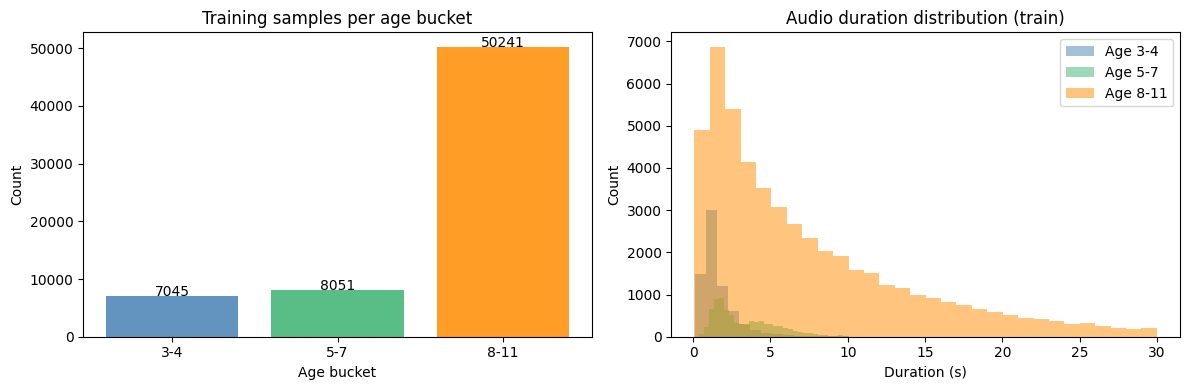

In [7]:
# ── 5. Dataset composition chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training sample counts
tr_counts = {b: len(bucket_train[b]) for b in AGE_BUCKETS}
axes[0].bar(tr_counts.keys(), tr_counts.values(),
            color=['steelblue', 'mediumseagreen', 'darkorange'], alpha=0.85)
axes[0].set(title='Training samples per age bucket',
            xlabel='Age bucket', ylabel='Count')
for i, (b, v) in enumerate(tr_counts.items()):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=10)

# Duration distribution per bucket
for bucket, color in zip(AGE_BUCKETS, ['steelblue', 'mediumseagreen', 'darkorange']):
    durs = [d['audio_duration_sec'] for d in bucket_train[bucket]]
    axes[1].hist(durs, bins=30, alpha=0.5, color=color, label=f'Age {bucket}')
axes[1].set(title='Audio duration distribution (train)', xlabel='Duration (s)', ylabel='Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(DATA_ROOT / "age_specific_data_overview.png", dpi=100)
plt.show()

In [8]:
# ── 6. Audio utility ──────────────────────────────────────────────────────────
def load_audio(audio_path_rel: str) -> np.ndarray:
    path = DATA_ROOT / audio_path_rel
    audio, sr = sf.read(str(path))
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    if sr != SAMPLE_RATE:
        audio = librosa.resample(audio.astype(np.float32),
                                 orig_sr=sr, target_sr=SAMPLE_RATE)
    return audio.astype(np.float32)


def transcribe(audio: np.ndarray, model, processor,
               max_new_tokens: int = 225) -> str:
    feat = processor.feature_extractor(
        audio, sampling_rate=SAMPLE_RATE, return_tensors="pt"
    )
    input_features = feat.input_features.to(device)
    with torch.no_grad():
        ids = model.generate(
            input_features=input_features,
            max_new_tokens=max_new_tokens,
        )
    return processor.tokenizer.batch_decode(ids, skip_special_tokens=True)[0]

In [9]:
# ── 7. Processor ──────────────────────────────────────────────────────────────
processor = WhisperProcessor.from_pretrained(
    MODEL_NAME, language="English", task="transcribe"
)
print("Vocab size:", processor.tokenizer.vocab_size)

Vocab size: 50258


In [10]:
# ── 8. Dataset & collator ─────────────────────────────────────────────────────
class WhisperSpeechDataset(Dataset):
    def __init__(self, records, processor):
        self.records   = records
        self.processor = processor

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        item  = self.records[idx]
        audio = load_audio(item['audio_path'])
        feat  = self.processor.feature_extractor(
            audio, sampling_rate=SAMPLE_RATE, return_tensors="pt"
        )
        input_features = feat.input_features.squeeze(0)
        labels = self.processor.tokenizer(
            item['orthographic_text'].lower(), return_tensors="pt"
        ).input_ids.squeeze(0)
        return {"input_features": input_features, "labels": labels}


@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: WhisperProcessor

    def __call__(self, features: List[Dict]) -> Dict[str, torch.Tensor]:
        input_features = torch.stack([f["input_features"] for f in features])
        label_list = [f["labels"] for f in features]
        max_len    = max(l.shape[0] for l in label_list)
        labels     = torch.full((len(label_list), max_len), -100, dtype=torch.long)
        for i, lbl in enumerate(label_list):
            labels[i, :lbl.shape[0]] = lbl
        return {"input_features": input_features, "labels": labels}

In [11]:
# ── 9. WER metric ─────────────────────────────────────────────────────────────
_transform = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.Strip(),
    jiwer.RemoveMultipleSpaces(),
    jiwer.ReduceToListOfListOfWords(),
])

def wer_score(refs, hyps):
    return jiwer.process_words(
        refs, hyps,
        reference_transform=_transform,
        hypothesis_transform=_transform,
    ).wer

def compute_metrics(pred):
    pred_ids  = pred.predictions
    label_ids = pred.label_ids.copy()
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
    pred_strs  = processor.tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
    label_strs = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)
    return {"wer": wer_score(label_strs, pred_strs)}

In [12]:
# ── 10. Helper: build a fresh LoRA-wrapped Whisper model ─────────────────────
def build_lora_model():
    base = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)
    forced_decoder_ids = processor.get_decoder_prompt_ids(
        language="english", task="transcribe"
    )
    base.config.forced_decoder_ids           = forced_decoder_ids
    base.config.suppress_tokens              = []
    base.config.use_cache                    = False
    base.generation_config.language          = "english"
    base.generation_config.task              = "transcribe"
    base.generation_config.forced_decoder_ids = forced_decoder_ids

    lora_config = LoraConfig(
        r              = LORA_R,
        lora_alpha     = LORA_ALPHA,
        target_modules = LORA_TARGET_MODULES,
        lora_dropout   = LORA_DROPOUT,
        bias           = "none",
        task_type      = TaskType.SEQ_2_SEQ_LM,
    )
    model = get_peft_model(base, lora_config).to(device)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.2f}%)")
    return model, forced_decoder_ids

In [13]:
# ── 11. Custom Trainer for Whisper + LoRA ─────────────────────────────────────
# Overrides compute_loss and prediction_step to bypass the two
# PeftModelForSeq2SeqLM incompatibilities with Whisper's forward signature.
# See notebook_whisper_lora.ipynb cell 10b for the full explanation.

class WhisperLoRATrainer(Seq2SeqTrainer):

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs = model.base_model.model(
            input_features=inputs["input_features"],
            labels=inputs["labels"],
        )
        return (outputs.loss, outputs) if return_outputs else outputs.loss

    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        if not self.args.predict_with_generate or prediction_loss_only:
            model.eval()
            inputs = self._prepare_inputs(inputs)
            with torch.no_grad():
                outputs = model.base_model.model(
                    input_features=inputs["input_features"],
                    labels=inputs["labels"],
                )
            return outputs.loss.detach(), None, None

        model.eval()
        inputs  = self._prepare_inputs(inputs)
        max_len = self.args.generation_max_length or 225
        with torch.no_grad():
            generated = model.generate(
                input_features=inputs["input_features"],
                max_new_tokens=max_len,
            )
        labels = inputs.get("labels")
        if generated.shape[-1] < max_len:
            generated = self._pad_tensors_to_max_len(generated, max_len)
        if labels is not None and labels.shape[-1] < max_len:
            labels = self._pad_tensors_to_max_len(labels, max_len)
        return None, generated, labels

In [14]:
# ── 12. Zero-shot WER per age bucket ─────────────────────────────────────────
print("=== Zero-shot evaluation ===")
zs_model, forced_decoder_ids = build_lora_model()
zs_base = zs_model.base_model.model.eval()

age_wer_zero = {}
for bucket in AGE_BUCKETS:
    preds, refs = [], []
    for item in bucket_eval[bucket]:
        audio = load_audio(item['audio_path'])
        preds.append(transcribe(audio, zs_base, processor))
        refs.append(item['orthographic_text'])
    age_wer_zero[bucket] = wer_score(refs, preds)
    print(f"  Zero-shot [{bucket}]  WER = {age_wer_zero[bucket]:.4f}  (n={len(refs)})")

del zs_base, zs_model
torch.cuda.empty_cache()

=== Zero-shot evaluation ===


/cs/student/project_msc/2025/dsml/nmxian/my-notebook/myenv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


  Trainable: 1,769,472 / 243,504,384  (0.73%)


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


  Zero-shot [3-4]  WER = 1.1423  (n=1496)
  Zero-shot [5-7]  WER = 0.5930  (n=1721)
  Zero-shot [8-11]  WER = 0.1762  (n=10862)


In [ ]:
# ── 13. Train one LoRA model per age bucket ───────────────────────────────────
# Models are trained sequentially (one GPU); each adapter is saved to disk
# so it can be reloaded later without retraining.

collator         = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)
age_wer_specific = {}   # filled after each bucket's training
log_histories    = {}   # training logs for plotting

for bucket in AGE_BUCKETS:
    print(f"\n{'='*60}")
    print(f"  Training age-specific model: [{bucket}]")
    print(f"  Train: {len(bucket_train[bucket])}  Eval: {len(bucket_eval[bucket])}")
    print('='*60)

    # Fresh LoRA-wrapped model for each bucket
    model, _ = build_lora_model()

    train_ds = WhisperSpeechDataset(bucket_train[bucket], processor)
    eval_ds  = WhisperSpeechDataset(bucket_eval[bucket],  processor)

    training_args = Seq2SeqTrainingArguments(
        output_dir                  = OUTPUT_DIRS[bucket],
        per_device_train_batch_size = BATCH_SIZE,
        per_device_eval_batch_size  = BATCH_SIZE,
        gradient_accumulation_steps = 1,
        warmup_steps                = 50,
        num_train_epochs            = NUM_EPOCHS,
        learning_rate               = LEARNING_RATE,
        fp16                        = torch.cuda.is_available(),
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "wer",
        greater_is_better           = False,
        predict_with_generate       = True,
        generation_max_length       = 225,
        logging_steps               = 25,
        report_to                   = "none",
        dataloader_num_workers      = 4,
        remove_unused_columns       = False,
        seed                        = SEED,
    )

    trainer = WhisperLoRATrainer(
        model           = model,
        args            = training_args,
        train_dataset   = train_ds,
        eval_dataset    = eval_ds,
        data_collator   = collator,
        compute_metrics = compute_metrics,
        tokenizer       = processor.feature_extractor,
    )

    trainer.train()

    # Save adapter
    model.save_pretrained(OUTPUT_DIRS[bucket])
    processor.save_pretrained(OUTPUT_DIRS[bucket])
    print(f"  Adapter saved → {OUTPUT_DIRS[bucket]}")

    # Evaluate on this bucket's eval set
    results = trainer.evaluate()
    age_wer_specific[bucket] = results['eval_wer']
    print(f"  [{bucket}]  Age-specific LoRA WER = {age_wer_specific[bucket]:.4f}")

    log_histories[bucket] = pd.DataFrame(trainer.state.log_history)

    del model, trainer, train_ds, eval_ds
    torch.cuda.empty_cache()

print("\nAll age-specific models trained.")


  Training age-specific model: [3-4]
  Train: 7045  Eval: 1496
  Trainable: 1,769,472 / 243,504,384  (0.73%)


/tmp/ipykernel_151358/714221140.py:44: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WhisperLoRATrainer.__init__`. Use `processing_class` instead.
  trainer = WhisperLoRATrainer(


Epoch,Training Loss,Validation Loss,Wer
1,0.542200,No log,0.551058
2,0.375400,No log,0.573016
3,0.184300,No log,0.547354


  Adapter saved → /cs/student/project_msc/2025/dsml/nmxian/comp0197-cw2/whisper_lora_age_3_4


  [3-4]  Age-specific LoRA WER = 0.5474

  Training age-specific model: [5-7]
  Train: 8051  Eval: 1721
  Trainable: 1,769,472 / 243,504,384  (0.73%)


...

Epoch,Training Loss,Validation Loss,Wer
1,0.138300,No log,0.158792
2,0.073400,No log,0.060637
3,0.018500,No log,0.054826


  Adapter saved → /cs/student/project_msc/2025/dsml/nmxian/comp0197-cw2/whisper_lora_age_5_7


  [5-7]  Age-specific LoRA WER = 0.0548

  Training age-specific model: [8-11]
  Train: 50241  Eval: 10862
  Trainable: 1,769,472 / 243,504,384  (0.73%)


/tmp/ipykernel_151358/714221140.py:44: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WhisperLoRATrainer.__init__`. Use `processing_class` instead.
  trainer = WhisperLoRATrainer(


Epoch,Training Loss,Validation Loss,Wer
1,0.288400,No log,0.124392


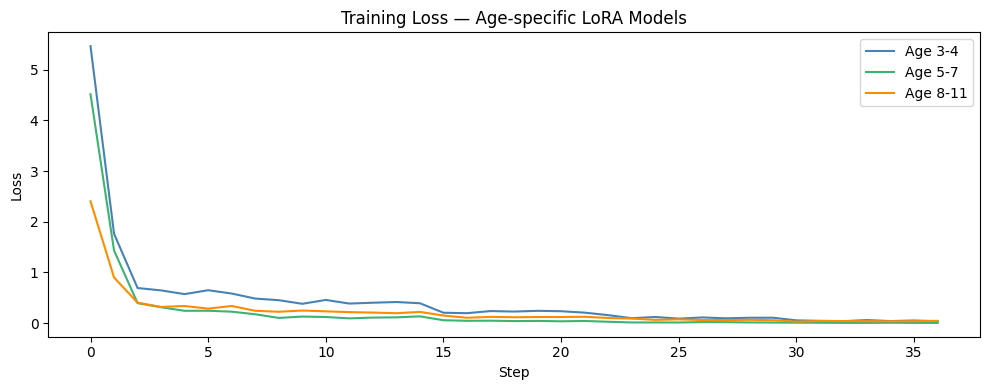

In [ ]:
# ── 14. Training loss curves ──────────────────────────────────────────────────
colors = {'3-4': 'steelblue', '5-7': 'mediumseagreen', '8-11': 'darkorange'}

fig, ax = plt.subplots(figsize=(10, 4))
for bucket in AGE_BUCKETS:
    log = log_histories[bucket]
    if 'loss' in log.columns:
        (log.dropna(subset=['loss'])['loss']
           .reset_index(drop=True)
           .plot(ax=ax, label=f'Age {bucket}', color=colors[bucket]))

ax.set(xlabel='Step', ylabel='Loss',
       title='Training Loss — Age-specific LoRA Models')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_ROOT / "age_specific_train_loss.png", dpi=100)
plt.show()

In [ ]:
# ── 15. Load general LoRA for comparison (if available) ───────────────────────
# The general LoRA was trained on a mixed-age dataset in notebook_whisper_lora.ipynb.
# Here we evaluate it on each bucket's eval set.

age_wer_general = {}
general_lora_available = Path(GENERAL_LORA_DIR).exists()

if general_lora_available:
    print(f"Loading general LoRA from {GENERAL_LORA_DIR}")
    base_gen = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)
    forced_decoder_ids = processor.get_decoder_prompt_ids(
        language="english", task="transcribe"
    )
    base_gen.config.forced_decoder_ids           = forced_decoder_ids
    base_gen.config.suppress_tokens              = []
    base_gen.generation_config.language          = "english"
    base_gen.generation_config.task              = "transcribe"
    base_gen.generation_config.forced_decoder_ids = forced_decoder_ids

    gen_model = PeftModel.from_pretrained(base_gen, GENERAL_LORA_DIR).to(device).eval()

    for bucket in AGE_BUCKETS:
        preds, refs = [], []
        for item in bucket_eval[bucket]:
            audio = load_audio(item['audio_path'])
            preds.append(transcribe(audio, gen_model, processor))
            refs.append(item['orthographic_text'])
        age_wer_general[bucket] = wer_score(refs, preds)
        print(f"  General LoRA [{bucket}]  WER = {age_wer_general[bucket]:.4f}")

    del gen_model, base_gen
    torch.cuda.empty_cache()
else:
    print(f"General LoRA adapter not found at {GENERAL_LORA_DIR}")
    print("Run notebook_whisper_lora.ipynb first, or skip this comparison.")
    # Fill with NaN so comparison cells still execute
    for bucket in AGE_BUCKETS:
        age_wer_general[bucket] = float('nan')

Loading general LoRA from /cs/student/project_msc/2025/dsml/nmxian/comp0197-cw2/whisper_lora
  General LoRA [3-4]  WER = 0.5400
  General LoRA [5-7]  WER = 0.2502
  General LoRA [8-11]  WER = 0.1328


In [ ]:
# ── 16. Cross-bucket evaluation (mismatched models) ──────────────────────────
# Optional sanity-check: apply each age-specific model to the OTHER buckets'
# eval sets.  A well-specialised model should score *higher* WER when evaluated
# out of distribution.

print("Cross-bucket WER matrix (row=model trained on, col=eval bucket)")
print(f"{'':15}", end='')
for col in AGE_BUCKETS:
    print(f"  eval [{col}]", end='')
print()

cross_wer = {}   # cross_wer[train_bucket][eval_bucket]

for train_bucket in AGE_BUCKETS:
    adapter_dir = OUTPUT_DIRS[train_bucket]
    base_cross  = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)
    base_cross.config.forced_decoder_ids           = forced_decoder_ids
    base_cross.config.suppress_tokens              = []
    base_cross.generation_config.language          = "english"
    base_cross.generation_config.task              = "transcribe"
    base_cross.generation_config.forced_decoder_ids = forced_decoder_ids

    cross_model = PeftModel.from_pretrained(base_cross, adapter_dir).to(device).eval()
    cross_wer[train_bucket] = {}

    print(f"  Model [{train_bucket}]     ", end='')
    for eval_bucket in AGE_BUCKETS:
        preds, refs = [], []
        for item in bucket_eval[eval_bucket]:
            audio = load_audio(item['audio_path'])
            preds.append(transcribe(audio, cross_model, processor))
            refs.append(item['orthographic_text'])
        w = wer_score(refs, preds)
        cross_wer[train_bucket][eval_bucket] = w
        marker = "◄" if train_bucket == eval_bucket else " "
        print(f"  {w:.4f}{marker}    ", end='')
    print()

    del cross_model, base_cross
    torch.cuda.empty_cache()

print("  (◄ = model evaluated on its own training-domain bucket)")

Cross-bucket WER matrix (row=model trained on, col=eval bucket)
                 eval [3-4]  eval [5-7]  eval [8-11]
  Model [3-4]       0.4978◄      0.7405       0.1735     
  Model [5-7]       0.8423       0.1173◄      0.3536     
  Model [8-11]       0.5994       0.5509       0.1246◄    
  (◄ = model evaluated on its own training-domain bucket)


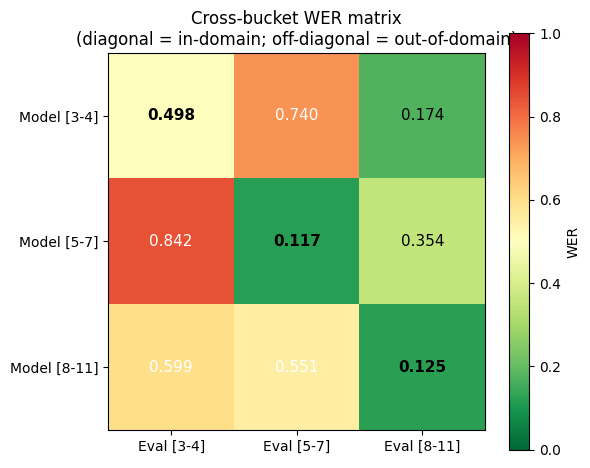

In [ ]:
# ── 17. Cross-bucket WER heatmap ──────────────────────────────────────────────
matrix = np.array([[cross_wer[r][c] for c in AGE_BUCKETS] for r in AGE_BUCKETS])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matrix, cmap='RdYlGn_r', vmin=0, vmax=1)
ax.set_xticks(range(len(AGE_BUCKETS)))
ax.set_yticks(range(len(AGE_BUCKETS)))
ax.set_xticklabels([f'Eval [{b}]' for b in AGE_BUCKETS])
ax.set_yticklabels([f'Model [{b}]' for b in AGE_BUCKETS])
ax.set_title('Cross-bucket WER matrix\n(diagonal = in-domain; off-diagonal = out-of-domain)')

for i in range(len(AGE_BUCKETS)):
    for j in range(len(AGE_BUCKETS)):
        ax.text(j, i, f'{matrix[i,j]:.3f}',
                ha='center', va='center',
                color='white' if matrix[i,j] > 0.5 else 'black',
                fontsize=11, fontweight='bold' if i == j else 'normal')

plt.colorbar(im, ax=ax, label='WER')
plt.tight_layout()
plt.savefig(DATA_ROOT / "age_specific_cross_wer.png", dpi=100)
plt.show()

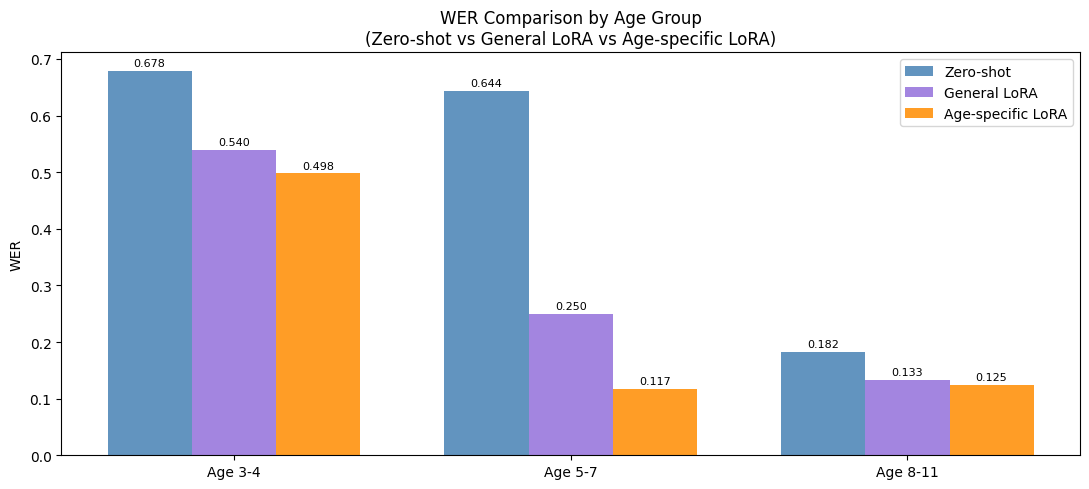


── WER improvement: age-specific LoRA vs zero-shot ──
Bucket     Zero-shot     General    Age-spec    Δ(spec-zero)     Rel %
  [3-4]       0.6782      0.5400      0.4978         -0.1803     -26.6%
  [5-7]       0.6441      0.2502      0.1173         -0.5268     -81.8%
  [8-11]       0.1819      0.1328      0.1246         -0.0573     -31.5%


In [ ]:
# ── 18. Side-by-side WER comparison ──────────────────────────────────────────
zero_vals    = [age_wer_zero[b]     for b in AGE_BUCKETS]
general_vals = [age_wer_general[b]  for b in AGE_BUCKETS]
specific_vals= [age_wer_specific[b] for b in AGE_BUCKETS]

has_general = not all(np.isnan(v) for v in general_vals)
n_bars = 3 if has_general else 2
w  = 0.25 if has_general else 0.35
x  = np.arange(len(AGE_BUCKETS))

fig, ax = plt.subplots(figsize=(11, 5))
if has_general:
    bars1 = ax.bar(x - w,  zero_vals,     w, label='Zero-shot',          color='steelblue',    alpha=0.85)
    bars2 = ax.bar(x,      general_vals,  w, label='General LoRA',       color='mediumpurple', alpha=0.85)
    bars3 = ax.bar(x + w,  specific_vals, w, label='Age-specific LoRA',  color='darkorange',   alpha=0.85)
    all_bars = list(bars1) + list(bars2) + list(bars3)
else:
    bars1 = ax.bar(x - w/2, zero_vals,     w, label='Zero-shot',         color='steelblue',  alpha=0.85)
    bars3 = ax.bar(x + w/2, specific_vals, w, label='Age-specific LoRA', color='darkorange', alpha=0.85)
    all_bars = list(bars1) + list(bars3)

for bar in all_bars:
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f'Age {b}' for b in AGE_BUCKETS])
ax.set(ylabel='WER',
       title='WER Comparison by Age Group\n(Zero-shot vs General LoRA vs Age-specific LoRA)')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_ROOT / "age_specific_wer_comparison.png", dpi=100)
plt.show()

# Delta table
print(f"\n── WER improvement: age-specific LoRA vs zero-shot ──")
print(f"{'Bucket':<8}  {'Zero-shot':>10}  {'General':>10}  {'Age-spec':>10}  {'Δ(spec-zero)':>14}  {'Rel %':>8}")
for b in AGE_BUCKETS:
    z = age_wer_zero[b]
    g = age_wer_general[b]
    s = age_wer_specific[b]
    delta = s - z
    rel   = delta / z * 100
    print(f"  [{b}]   {z:10.4f}  {g:10.4f}  {s:10.4f}  {delta:+14.4f}  {rel:+8.1f}%")

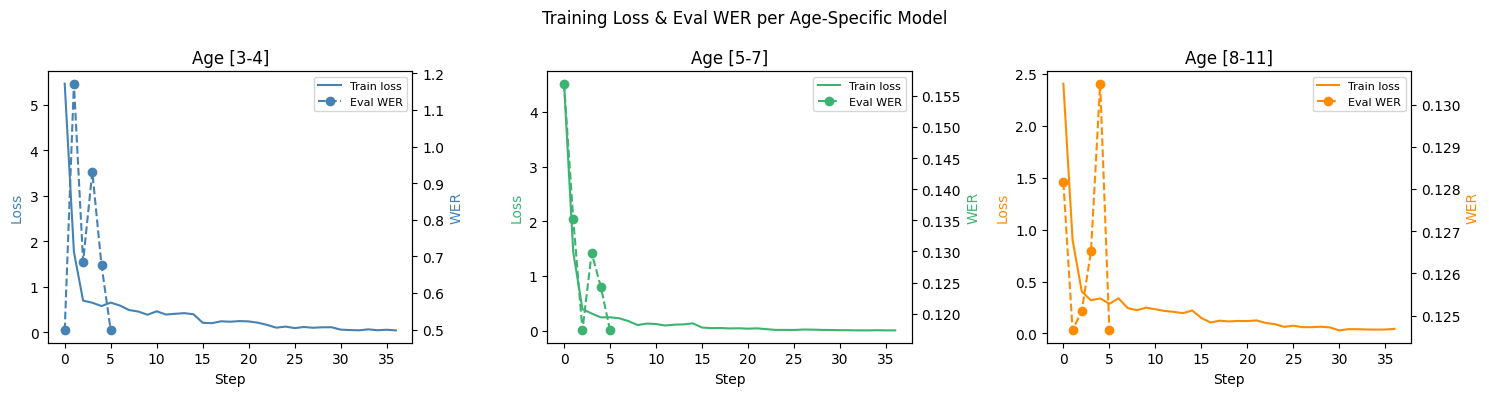

In [ ]:
# ── 19. Per-bucket training loss vs eval WER curves ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, bucket in zip(axes, AGE_BUCKETS):
    log   = log_histories[bucket]
    color = colors[bucket]

    ax2 = ax.twinx()

    if 'loss' in log.columns:
        train_log = log.dropna(subset=['loss']).reset_index(drop=True)
        ax.plot(train_log.index, train_log['loss'],
                color=color, linewidth=1.5, label='Train loss')

    if 'eval_wer' in log.columns:
        eval_log = log.dropna(subset=['eval_wer']).reset_index(drop=True)
        ax2.plot(eval_log.index, eval_log['eval_wer'],
                 color=color, linestyle='--', linewidth=1.5, marker='o',
                 label='Eval WER')

    ax.set(title=f'Age [{bucket}]', xlabel='Step')
    ax.set_ylabel('Loss', color=color)
    ax2.set_ylabel('WER', color=color)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

plt.suptitle('Training Loss & Eval WER per Age-Specific Model')
plt.tight_layout()
plt.savefig(DATA_ROOT / "age_specific_learning_curves.png", dpi=100)
plt.show()

In [ ]:
# ── 20. Qualitative examples per bucket ───────────────────────────────────────
# Reload each age-specific adapter and show 5 reference / hypothesis pairs.

N_EXAMPLES = 5
print("Qualitative transcription examples per age-specific model\n")

for bucket in AGE_BUCKETS:
    print(f"{'─'*55}")
    print(f"  Age bucket [{bucket}]")
    print(f"{'─'*55}")

    base_q = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)
    base_q.config.forced_decoder_ids           = forced_decoder_ids
    base_q.config.suppress_tokens              = []
    base_q.generation_config.language          = "english"
    base_q.generation_config.task              = "transcribe"
    base_q.generation_config.forced_decoder_ids = forced_decoder_ids

    q_model = PeftModel.from_pretrained(base_q, OUTPUT_DIRS[bucket]).to(device).eval()

    for item in bucket_eval[bucket][:N_EXAMPLES]:
        audio = load_audio(item['audio_path'])
        hyp   = transcribe(audio, q_model, processor)
        w     = wer_score([item['orthographic_text']], [hyp])
        print(f"  Ref : {item['orthographic_text']}")
        print(f"  Hyp : {hyp}")
        print(f"  WER : {w:.3f}")
        print()

    del q_model, base_q
    torch.cuda.empty_cache()

Qualitative transcription examples per age-specific model

───────────────────────────────────────────────────────
  Age bucket [3-4]
───────────────────────────────────────────────────────
  Ref : what is it is that
  Hyp : lamping it with a house house
  WER : 1.200

  Ref : a ring
  Hyp : a ring
  WER : 0.000

  Ref : you take off your shirt
  Hyp : the um pick up your shirt
  WER : 0.800

  Ref : sitting
  Hyp : sitting
  WER : 0.000

  Ref : a monkey
  Hyp : oops
  WER : 1.000

───────────────────────────────────────────────────────
  Age bucket [5-7]
───────────────────────────────────────────────────────
  Ref : those loud creaky doors are finally fixed
  Hyp : so much fun to play together today
  WER : 1.000

  Ref : put the food in the freezer before you leave
  Hyp : put the food in the freezer before you leave
  WER : 0.000

  Ref : strawberry
  Hyp : strawberry
  WER : 0.000

  Ref : the pencils she brought for the test were sharpened and put in her bag
  Hyp : the pencils 

In [ ]:
# ── 21. Summary ───────────────────────────────────────────────────────────────
print("=" * 65)
print("SUMMARY — Age-Specific Whisper-small + LoRA")
print("=" * 65)
print(f"Base model       : {MODEL_NAME}")
print(f"LoRA rank/alpha  : r={LORA_R}, α={LORA_ALPHA}")
print(f"Epochs           : {NUM_EPOCHS}")
print(f"Train per bucket : {NUM_TRAIN_PER_BUCKET:,}")
print(f"Eval  per bucket : {NUM_EVAL_PER_BUCKET:,}")
print()

col_w = 12
header = f"  {'Bucket':<8}  {'Zero-shot':>{col_w}}  {'General LoRA':>{col_w}}  {'Age-spec LoRA':>{col_w}}  {'Gain vs zero':>{col_w}}"
print(header)
print("  " + "-" * (len(header) - 2))
for b in AGE_BUCKETS:
    z = age_wer_zero[b]
    g = age_wer_general[b]
    s = age_wer_specific[b]
    gain = (z - s) / z * 100
    g_str = f"{g:.4f}" if not np.isnan(g) else "  n/a   "
    print(f"  [{b}]      {z:{col_w}.4f}  {g_str:>{col_w}}  {s:{col_w}.4f}  {gain:>+{col_w}.1f}%")

print()
print("Cross-bucket WER matrix (model → eval):")
print(f"  {'Model    Eval':<14}", end='')
for col in AGE_BUCKETS:
    print(f"  [{col}]  ", end='')
print()
for row in AGE_BUCKETS:
    print(f"  Model [{row}]     ", end='')
    for col in AGE_BUCKETS:
        marker = "◄" if row == col else " "
        print(f"  {cross_wer[row][col]:.4f}{marker} ", end='')
    print()
print()
print("Key findings:")
for b in AGE_BUCKETS:
    z = age_wer_zero[b]; s = age_wer_specific[b]
    direction = "↓ improved" if s < z else "↑ degraded"
    print(f"  [{b}]  {direction} by {abs(z-s)/z*100:.1f}% (zero-shot {z:.4f} → age-specific {s:.4f})")

SUMMARY — Age-Specific Whisper-small + LoRA
Base model       : openai/whisper-small
LoRA rank/alpha  : r=16, α=32
Epochs           : 5
Train per bucket : 3,000
Eval  per bucket : 300

  Bucket       Zero-shot  General LoRA  Age-spec LoRA  Gain vs zero
  -----------------------------------------------------------------
  [3-4]            0.6782        0.5400        0.4978         +26.6%
  [5-7]            0.6441        0.2502        0.1173         +81.8%
  [8-11]            0.1819        0.1328        0.1246         +31.5%

Cross-bucket WER matrix (model → eval):
  Model    Eval   [3-4]    [5-7]    [8-11]  
  Model [3-4]       0.4978◄   0.7405    0.1735  
  Model [5-7]       0.8423    0.1173◄   0.3536  
  Model [8-11]       0.5994    0.5509    0.1246◄ 

Key findings:
  [3-4]  ↓ improved by 26.6% (zero-shot 0.6782 → age-specific 0.4978)
  [5-7]  ↓ improved by 81.8% (zero-shot 0.6441 → age-specific 0.1173)
  [8-11]  ↓ improved by 31.5% (zero-shot 0.1819 → age-specific 0.1246)
